# Machine Learning Model Training

## Week 5: Build, Train, and Evaluate Your First ML Models

In this notebook, we'll build regression and classification models from scratch.

---

## Setup: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


## Load & Prepare Data

In [5]:
# Create sample dataset
np.random.seed(42)
n_samples = 100

df = pd.DataFrame({
    'Age': np.random.uniform(22, 65, n_samples),
    'YearsExperience': np.random.uniform(0, 40, n_samples),
    'Education': np.random.choice(['HighSchool', 'Bachelor', 'Master'], n_samples),
    'Department': np.random.choice(['Sales', 'IT', 'HR'], n_samples)
})

# Create target variables
df['Salary'] = 30000 + df['YearsExperience'] * 2000 + df['Age'] * 500 + np.random.normal(0, 5000, n_samples)
df['HighEarner'] = (df['Salary'] > df['Salary'].median()).astype(int)  # Binary classification

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (100, 6)

First few rows:
         Age  YearsExperience   Education Department         Salary  \
0  38.105225         1.257167      Master         IT   46932.295052   
1  62.880715        25.456416  HighSchool         HR  112055.563709   
2  53.475739        12.574239    Bachelor         IT   65680.011535   
3  47.742315        20.342828    Bachelor      Sales   89434.874497   
4  28.708802        36.302659      Master      Sales  115696.877927   

   HighEarner  
0           0  
1           1  
2           0  
3           1  
4           1  

Data types:
Age                float64
YearsExperience    float64
Education              str
Department             str
Salary             float64
HighEarner           int64
dtype: object


## Part 1: REGRESSION - Predicting Salary

### Step 1: Prepare Features

In [6]:
# Select features for regression
X_regression = df[['Age', 'YearsExperience']]
y_regression = df['Salary']

print(f"Features shape: {X_regression.shape}")
print(f"Target shape: {y_regression.shape}")
print(f"\nFeature statistics:")
print(X_regression.describe())

Features shape: (100, 2)
Target shape: (100,)

Feature statistics:
              Age  YearsExperience
count  100.000000       100.000000
mean    42.217772        19.913269
std     12.792045        11.724450
min     22.237451         0.278085
25%     30.307633         9.680181
50%     41.958126        20.224994
75%     53.398734        30.647344
max     64.436138        39.426018


### Step 2: Train-Test Split

In [7]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 80
Test set size: 20


### Step 3: Scale Features

In [12]:
# Standardize features (important for many algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled successfully!")
print(f"Train mean: {X_train_scaled.mean(axis=0)}")

Features scaled successfully!
Train mean: [3.55271368e-16 2.95596880e-16]


### Step 4: Train Linear Regression Model

In [13]:
# Create and train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained!")
print(f"\nModel Coefficients:")
print(f"  Age: {lr_model.coef_[0]:,.0f}")
print(f"  Years Experience: {lr_model.coef_[1]:,.0f}")
print(f"Intercept: {lr_model.intercept_:,.0f}")

Linear Regression Model Trained!

Model Coefficients:
  Age: 5,794
  Years Experience: 23,500
Intercept: 91,219


### Step 5: Make Predictions

In [14]:
# Predict on test set
y_pred = lr_model.predict(X_test_scaled)

print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual values: {y_test.values[:5]}")

First 5 predictions: [113628.11437761  98478.14110124 111406.78608685  56885.27906688
  69109.09477427]
First 5 actual values: [110018.93692477 103462.5570364  111747.17762303  58781.82181852
  69246.50118478]


### Step 6: Evaluate Model

In [15]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*50)
print("LINEAR REGRESSION EVALUATION")
print("="*50)
print(f"Mean Squared Error (MSE): ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation:")
print(f"  - RMSE: On average, predictions are off by ${rmse:,.0f}")
print(f"  - R²: Model explains {r2*100:.1f}% of salary variance")

LINEAR REGRESSION EVALUATION
Mean Squared Error (MSE): $14,437,525.36
Root Mean Squared Error (RMSE): $3,799.67
R² Score: 0.9792

Interpretation:
  - RMSE: On average, predictions are off by $3,800
  - R²: Model explains 97.9% of salary variance


### Step 7: Visualize Results

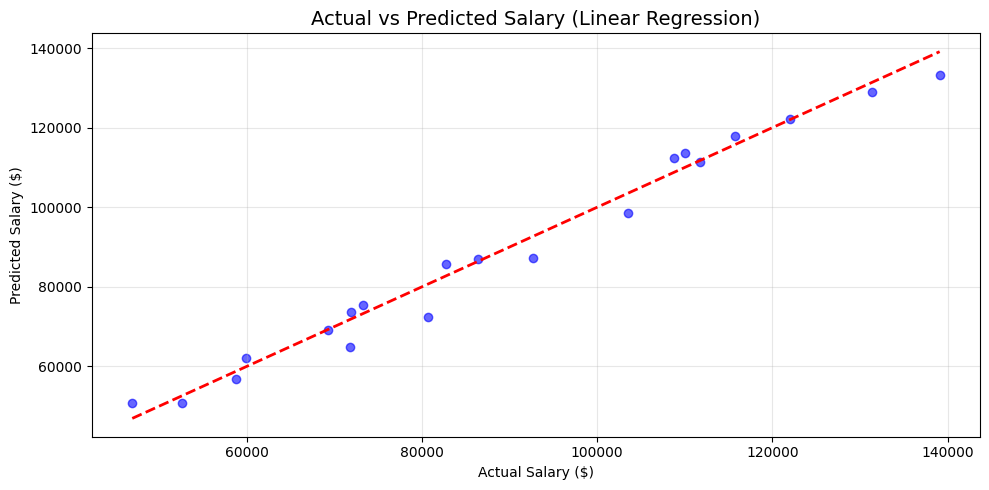

In [16]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Salary (Linear Regression)', fontsize=14)
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 2: CLASSIFICATION - Predicting High Earners

### Step 1: Prepare Features

In [17]:
# Select features for classification
X_classification = df[['Age', 'YearsExperience']]
y_classification = df['HighEarner']

print(f"Class distribution:")
print(y_classification.value_counts())
print(f"\nClass percentages:")
print(y_classification.value_counts(normalize=True) * 100)

Class distribution:
HighEarner
0    50
1    50
Name: count, dtype: int64

Class percentages:
HighEarner
0    50.0
1    50.0
Name: proportion, dtype: float64


### Step 2: Train-Test Split

In [18]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# Scale features
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(f"Training set: {len(X_train_clf)} samples")
print(f"Test set: {len(X_test_clf)} samples")

Training set: 80 samples
Test set: 20 samples


### Step 3: Train Decision Tree

In [19]:
# Create and train decision tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_clf_scaled, y_train_clf)

# Make predictions
y_pred_dt = dt_model.predict(X_test_clf_scaled)

print("Decision Tree Model Trained!")
print(f"Feature Importance:")
for feature, importance in zip(X_classification.columns, dt_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")

Decision Tree Model Trained!
Feature Importance:
  Age: 0.1201
  YearsExperience: 0.8799


### Step 4: Evaluate Decision Tree

In [20]:
# Calculate metrics
accuracy_dt = accuracy_score(y_test_clf, y_pred_dt)
precision_dt = precision_score(y_test_clf, y_pred_dt)
recall_dt = recall_score(y_test_clf, y_pred_dt)
f1_dt = f1_score(y_test_clf, y_pred_dt)

print("="*50)
print("DECISION TREE EVALUATION")
print("="*50)
print(f"Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.1f}%)")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_dt))

DECISION TREE EVALUATION
Accuracy: 0.9500 (95.0%)
Precision: 0.9091
Recall: 1.0000
F1-Score: 0.9524

Confusion Matrix:
[[ 9  1]
 [ 0 10]]


### Step 5: Train Random Forest

In [21]:
# Create and train random forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_clf_scaled, y_train_clf)

# Make predictions
y_pred_rf = rf_model.predict(X_test_clf_scaled)

# Calculate metrics
accuracy_rf = accuracy_score(y_test_clf, y_pred_rf)
precision_rf = precision_score(y_test_clf, y_pred_rf)
recall_rf = recall_score(y_test_clf, y_pred_rf)
f1_rf = f1_score(y_test_clf, y_pred_rf)

print("="*50)
print("RANDOM FOREST EVALUATION")
print("="*50)
print(f"Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.1f}%)")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

RANDOM FOREST EVALUATION
Accuracy: 1.0000 (100.0%)
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


### Step 6: Model Comparison

In [22]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_dt, accuracy_rf],
    'Precision': [precision_dt, precision_rf],
    'Recall': [recall_dt, recall_rf],
    'F1-Score': [f1_dt, f1_rf]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print(f"\n✓ BEST MODEL: Random Forest" if accuracy_rf > accuracy_dt else f"\n✓ BEST MODEL: Decision Tree")


MODEL COMPARISON
        Model  Accuracy  Precision  Recall  F1-Score
Decision Tree      0.95   0.909091     1.0  0.952381
Random Forest      1.00   1.000000     1.0  1.000000

✓ BEST MODEL: Random Forest


## Summary & Next Steps

### What We Accomplished:
✅ Built a linear regression model to predict salary
✅ Evaluated regression with R² and RMSE
✅ Built decision tree classifier
✅ Built random forest classifier
✅ Evaluated classification with Accuracy, Precision, Recall, F1
✅ Compared multiple models

### Key Takeaways:
1. Always split data into train and test sets
2. Scale features before training
3. Choose appropriate metrics for your problem
4. Compare multiple models before selecting best
5. Interpret results in business context

### Next Week:
Week 6: MLOps & Model Improvement - Hyperparameter tuning, cross-validation, and deployment prep!